# 02 - Baseline CNN

Notebook de premiere experience avec un CNN simple entraine from scratch.

In [1]:
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ROOT_DIR = Path.cwd().parents[0]
DATA_DIR = ROOT_DIR / 'data'
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16
SEED = 42


def build_baseline_cnn(input_shape=(256, 256, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs, name='baseline_cnn')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mae', metrics=['mae', 'mse'])
    return model


def create_dataset_from_directory(dataset_dir: Path):
    if not dataset_dir.exists():
        raise FileNotFoundError(f'Dossier data introuvable: {dataset_dir}')
    return tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        validation_split=0.2,
        subset='training',
        seed=SEED,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='int',
    )


print('Fonctions de la baseline CNN pretes pour entrainement.')

Fonctions de la baseline CNN pretes pour entrainement.


## Chargement des donnees

In [2]:
# charger le CSV
import pandas as pd
from sklearn.model_selection import train_test_split

csv_path = DATA_DIR / 'boneage-training-dataset.csv'
df = pd.read_csv(csv_path)

# construire les chemins d'images
train_img_dir = DATA_DIR / 'boneage-training-dataset' / 'boneage-training-dataset'
df['filepath'] = df['id'].apply(lambda x: str(train_img_dir / f'{x}.png'))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)
print(f'Train: {len(train_df)}, Val: {len(val_df)}')

Train: 10088, Val: 2523


In [3]:
# creer les datasets avec tf.data
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_paths = train_df['filepath'].tolist()
train_labels = train_df['boneage'].astype('float32').tolist()
val_paths = val_df['filepath'].tolist()
val_labels = val_df['boneage'].astype('float32').tolist()

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'Train ds: {train_ds}, Val ds: {val_ds}')

Train ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>, Val ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## Entrainement

In [4]:
# construire et entrainer le modele
model = build_baseline_cnn(input_shape=(256, 256, 3))
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,870,721 (64.36 MB)

 Trainable params: 16,870,721 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# entrainement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 398s 620ms/step - loss: 35.2130 - mae: 35.2130 - mse: 2006.8650 - val_loss: 34.6211 - val_mae: 34.6211 - val_mse: 1772.9615
Epoch 2/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 389s 612ms/step - loss: 33.9466 - mae: 33.9466 - mse: 1805.6951 - val_loss: 34.0760 - val_mae: 34.0760 - val_mse: 1870.6748
Epoch 3/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 447s 704ms/step - loss: 33.5221 - mae: 33.5221 - mse: 1771.5029 - val_loss: 34.5140 - val_mae: 34.5140 - val_mse: 1962.4393
Epoch 4/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 454s 713ms/step - loss: 33.5771 - mae: 33.5771 - mse: 1790.7678 - val_loss: 33.9795 - val_mae: 33.9795 - val_mse: 1784.3894
Epoch 5/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 408s 641ms/step - loss: 33.5396 - mae: 33.5396 - mse: 1769.2639 - val_loss: 33.9717 - val_mae: 33.9717 - val_mse: 1814.4049
Epoch 6/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 491s 773ms/step - loss: 33.7357 - mae: 33.7357 - mse: 1809.3593 - val_loss: 35.8613 - val_mae: 35.8613 - val_mse: 1843.7880
Epoch 7/10
631/6

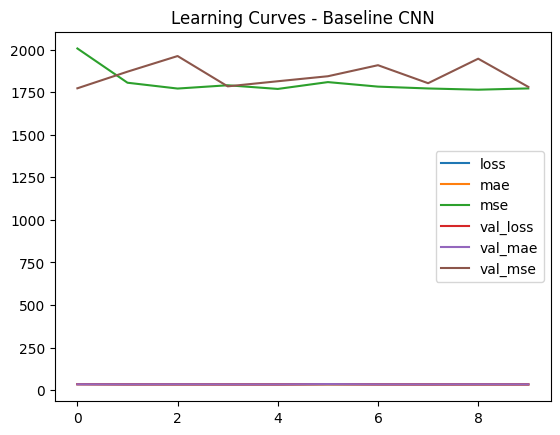

MAE sur validation: 33.95 mois


In [6]:
# visualiser les resultats
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

pd.DataFrame(history.history).plot()
plt.title('Learning Curves - Baseline CNN')
plt.show()

# evaluation
y_pred = model.predict(val_ds, verbose=0).flatten()
y_true = np.array(val_labels)
mae = mean_absolute_error(y_true, y_pred)
print(f'MAE sur validation: {mae:.2f} mois')